In [1]:
!pip install opencv-python

In [2]:
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()
print(uploaded.keys())

Saving IMG_4997.jpg to IMG_4997.jpg
Saving IMG_4998.jpg to IMG_4998.jpg
Saving IMG_4999.jpg to IMG_4999.jpg
dict_keys(['IMG_4997.jpg', 'IMG_4998.jpg', 'IMG_4999.jpg'])


불러온 이미지 개수: 3
PANORAMA status: 0
스티칭 성공! dst shape: (1900, 2216, 3)


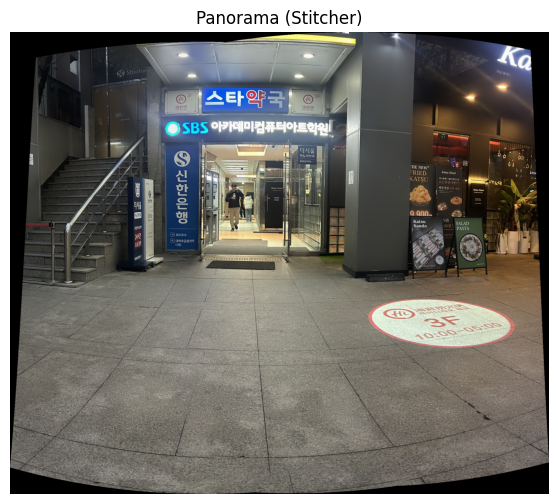

output.jpg 저장 완료


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 파일 이름을 업로드된 이름으로 바꾸기
img_names = ['IMG_4997.jpg', 'IMG_4998.jpg', 'IMG_4999.jpg']  # 왼쪽, 가운데, 오른쪽 순서

# 2. 이미지 읽기 + (선택) 리사이즈
imgs = []
max_width = 1600  # 너무 크면 줄여서 안정성 확보

for name in img_names:
    img = cv2.imread(name)
    if img is None:
        print('Image load failed! ->', name)
        raise SystemExit()

    h, w = img.shape[:2]
    if w > max_width:
        scale = max_width / w
        img = cv2.resize(img, (int(w*scale), int(h*scale)))

    imgs.append(img)

print("불러온 이미지 개수:", len(imgs))

def run_stitch(mode):
    if mode == 'PANORAMA':
        stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
    else:  # 'SCANS'
        stitcher = cv2.Stitcher_create(cv2.Stitcher_SCANS)

    status, dst = stitcher.stitch(imgs)
    return status, dst

# 3. 먼저 PANORAMA 모드로 시도
status, dst = run_stitch('PANORAMA')
print('PANORAMA status:', status)

# 4. 안 되면 SCANS 모드로 한 번 더 시도
if status != cv2.Stitcher_OK:
    print("PANORAMA 실패, SCANS 모드로 재시도한다.")
    status, dst = run_stitch('SCANS')
    print('SCANS status:', status)

if status != cv2.Stitcher_OK:
    print("두 모드 모두 스티칭 실패… status 코드:", status)
else:
    print("스티칭 성공! dst shape:", dst.shape)

    # 5. 결과 표시
    plt.figure(figsize=(15, 6))
    plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Panorama (Stitcher)")
    plt.show()

    # 6. 결과 저장
    cv2.imwrite('output.jpg', dst)
    print("output.jpg 저장 완료")
